In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = "../../data/raw/era5/reanalysis-era5-land-timeseries-sfc-2m-temperaturepyi4tsmb.nc"

ds = xr.open_dataset(DATA_PATH)

In [3]:
ds

<xarray.Dataset> Size: 654kB
Dimensions:     (valid_time: 2208, latitude: 6, longitude: 6)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 18kB 2026-05-01 ... 2026-07-31T23...
  * latitude    (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude   (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Data variables:
    d2m         (valid_time, latitude, longitude) float32 318kB ...
    t2m         (valid_time, latitude, longitude) float32 318kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [4]:
print(ds["t2m"])

<xarray.DataArray 't2m' (valid_time: 2208, latitude: 6, longitude: 6)> Size: 318kB
[79488 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 18kB 2026-05-01 ... 2026-07-31T23...
  * latitude    (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude   (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1801
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    uni

In [5]:
print(ds["t2m"].attrs)

{'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(3600), 'GRIB_Ny': np.int64(1801), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 't2m', 'GRIB_dataType': 'fc', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_gridType': 'regular_ll', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.1), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.1), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(90.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-90.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(359.9), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': '2 metre temperature', 'GRIB_numberOfPoints': np.int64(6483600), 'GRIB_paramId': np.int64(167), 'GRIB_shortName': '2t', 'GRIB_stepType': 'instant', 'GRIB_stepUnits': np.int64(1), 'GRIB_totalNumber': np.int64(0), 'GRIB

In [6]:
ds["t2m"].attrs.get("units")

'K'

In [7]:
ds["temperature_c"] = ds["t2m"] - 273.15

In [8]:
ds["dewpoint_c"] = ds["d2m"] - 273.15


In [9]:
ds[["temperature_c", "dewpoint_c"]]

<xarray.Dataset> Size: 654kB
Dimensions:        (valid_time: 2208, latitude: 6, longitude: 6)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 18kB 2026-05-01 ... 2026-07-31...
  * latitude       (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude      (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Data variables:
    temperature_c  (valid_time, latitude, longitude) float32 318kB 27.65 ... ...
    dewpoint_c     (valid_time, latitude, longitude) float32 318kB 26.38 ... ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [10]:
ds["temperature_c"].attrs["long_name"] = "2 metre temperature"
ds["temperature_c"].attrs["units"] = "°C"

In [11]:
ds["dewpoint_c"].attrs["long_name"] = "2 metre dewpoint temperature"
ds["dewpoint_c"].attrs["units"] = "°C"

In [12]:
ds[["temperature_c", "dewpoint_c"]]

<xarray.Dataset> Size: 654kB
Dimensions:        (valid_time: 2208, latitude: 6, longitude: 6)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 18kB 2026-05-01 ... 2026-07-31...
  * latitude       (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude      (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Data variables:
    temperature_c  (valid_time, latitude, longitude) float32 318kB 27.65 ... ...
    dewpoint_c     (valid_time, latitude, longitude) float32 318kB 26.38 ... ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [13]:
print("Temperature")
print("Min :", ds["temperature_c"].min().item(), "°C")
print("Max :", ds["temperature_c"].max().item(), "°C")
print("Mean:", ds["temperature_c"].mean().item(), "°C")

print("\nDew Point")
print("Min :", ds["dewpoint_c"].min().item(), "°C")
print("Max :", ds["dewpoint_c"].max().item(), "°C")
print("Mean:", ds["dewpoint_c"].mean().item(), "°C")

Temperature
Min : 24.9822998046875 °C
Max : 41.8154296875 °C
Mean: 30.095643997192383 °C

Dew Point
Min : 16.52142333984375 °C
Max : 28.4609375 °C
Mean: 25.64795684814453 °C


In [14]:
print("Missing temperature:",
      ds["temperature_c"].isnull().sum().item())

print("Missing dew point:",
      ds["dewpoint_c"].isnull().sum().item())

Missing temperature: 0
Missing dew point: 0


In [15]:
from pathlib import Path
import xarray as xr

era5_dir = Path("../../data/raw/era5")

nc_files = sorted(era5_dir.glob("*.nc"))

for file in nc_files:
    print("\nFILE:", file.name)

    ds_tmp = xr.open_dataset(file)

    print("Variables:", list(ds_tmp.data_vars))
    print("Dimensions:", dict(ds_tmp.sizes))

    ds_tmp.close()


FILE: reanalysis-era5-land-timeseries-sfc-2m-temperaturepyi4tsmb.nc
Variables: ['d2m', 't2m']
Dimensions: {'valid_time': 2208, 'latitude': 6, 'longitude': 6}

FILE: reanalysis-era5-land-timeseries-sfc-pressure-precipitationpicq7e_6.nc
Variables: ['sp']
Dimensions: {'valid_time': 2208, 'latitude': 6, 'longitude': 6}

FILE: reanalysis-era5-land-timeseries-sfc-radiation-heatkn38r9do.nc
Variables: ['ssrd', 'strd']
Dimensions: {'valid_time': 2208, 'latitude': 6, 'longitude': 6}

FILE: reanalysis-era5-land-timeseries-sfc-windb5kj6dv8.nc
Variables: ['u10', 'v10']
Dimensions: {'valid_time': 2208, 'latitude': 6, 'longitude': 6}


In [16]:
datasets = [xr.open_dataset(file) for file in nc_files]

full_ds = xr.merge(datasets)

full_ds

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 2208, latitude: 6, longitude: 6)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 18kB 2026-05-01 ... 2026-07-31T23...
  * latitude    (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude   (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Data variables:
    d2m         (valid_time, latitude, longitude) float32 318kB ...
    t2m         (valid_time, latitude, longitude) float32 318kB ...
    sp          (valid_time, latitude, longitude) float32 318kB ...
    ssrd        (valid_time, latitude, longitude) float32 318kB ...
    strd        (valid_time, latitude, longitude) float32 318kB ...
    u10         (valid_time, latitude, longitude) float32 318kB ...
    v10         (valid_time, latitude, longitude) float32 318kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [17]:
print("Variables:")
print(list(full_ds.data_vars))

print("\nDimensions:")
print(dict(full_ds.sizes))

Variables:
['d2m', 't2m', 'sp', 'ssrd', 'strd', 'u10', 'v10']

Dimensions:
{'valid_time': 2208, 'latitude': 6, 'longitude': 6}


In [18]:
for variable in full_ds.data_vars:
    missing = full_ds[variable].isnull().sum().item()
    print(f"{variable}: {missing} missing values")

d2m: 0 missing values
t2m: 0 missing values
sp: 0 missing values
ssrd: 0 missing values
strd: 0 missing values
u10: 0 missing values
v10: 0 missing values


In [19]:
for variable in full_ds.data_vars:
    print(
        variable,
        "->",
        full_ds[variable].attrs.get("long_name"),
        "| unit:",
        full_ds[variable].attrs.get("units")
    )

d2m -> 2 metre dewpoint temperature | unit: K
t2m -> 2 metre temperature | unit: K
sp -> Surface pressure | unit: Pa
ssrd -> Surface solar radiation downwards | unit: J m**-2
strd -> Surface thermal radiation downwards | unit: J m**-2
u10 -> 10 metre U wind component | unit: m s**-1
v10 -> 10 metre V wind component | unit: m s**-1


In [20]:
import numpy as np

processed_ds = full_ds.copy()

processed_ds["temperature_c"] = processed_ds["t2m"] - 273.15
processed_ds["dewpoint_c"] = processed_ds["d2m"] - 273.15

processed_ds["wind_speed_ms"] = np.sqrt(
    processed_ds["u10"] ** 2 +
    processed_ds["v10"] ** 2
)
processed_ds["temperature_c"].attrs = {
    "long_name": "2 metre air temperature",
    "units": "°C"
}

processed_ds["dewpoint_c"].attrs = {
    "long_name": "2 metre dewpoint temperature",
    "units": "°C"
}

processed_ds["wind_speed_ms"].attrs = {
    "long_name": "10 metre wind speed",
    "units": "m s^-1"
}
T = processed_ds["temperature_c"]
Td = processed_ds["dewpoint_c"]

processed_ds["relative_humidity_pct"] = (
    100
    * np.exp((17.625 * Td) / (243.04 + Td))
    / np.exp((17.625 * T) / (243.04 + T))
)
processed_ds["relative_humidity_pct"].attrs = {
    "long_name": "Relative humidity",
    "units": "%"
}

In [21]:
processed_ds["solar_radiation_wm2"] = processed_ds["ssrd"] / 3600
processed_ds["thermal_radiation_wm2"] = processed_ds["strd"] / 3600
processed_ds["solar_radiation_wm2"].attrs = {
    "long_name": "Surface solar radiation downward flux",
    "units": "W m^-2"
}

processed_ds["thermal_radiation_wm2"].attrs = {
    "long_name": "Surface thermal radiation downward flux",
    "units": "W m^-2"
}
processed_ds["surface_pressure_pa"] = processed_ds["sp"]

processed_ds["surface_pressure_pa"].attrs = {
    "long_name": "Surface pressure",
    "units": "Pa"
}

In [22]:
weather_ds = processed_ds[
    [
        "temperature_c",
        "dewpoint_c",
        "relative_humidity_pct",
        "wind_speed_ms",
        "surface_pressure_pa",
        "solar_radiation_wm2",
        "thermal_radiation_wm2",
    ]
]

In [23]:
weather_ds

<xarray.Dataset> Size: 2MB
Dimensions:                (valid_time: 2208, latitude: 6, longitude: 6)
Coordinates:
  * valid_time             (valid_time) datetime64[ns] 18kB 2026-05-01 ... 20...
  * latitude               (latitude) float64 48B 20.0 20.1 20.2 20.3 20.4 20.5
  * longitude              (longitude) float64 48B 85.6 85.7 85.8 85.9 86.0 86.1
Data variables:
    temperature_c          (valid_time, latitude, longitude) float32 318kB 27...
    dewpoint_c             (valid_time, latitude, longitude) float32 318kB 26...
    relative_humidity_pct  (valid_time, latitude, longitude) float32 318kB 92...
    wind_speed_ms          (valid_time, latitude, longitude) float32 318kB 6....
    surface_pressure_pa    (valid_time, latitude, longitude) float32 318kB 1....
    solar_radiation_wm2    (valid_time, latitude, longitude) float32 318kB 0....
    thermal_radiation_wm2  (valid_time, latitude, longitude) float32 318kB 43...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [24]:
for var in weather_ds.data_vars:
    print(
        var,
        "| min:", weather_ds[var].min().item(),
        "| max:", weather_ds[var].max().item()
    )

temperature_c | min: 24.9822998046875 | max: 41.8154296875
dewpoint_c | min: 16.52142333984375 | max: 28.4609375
relative_humidity_pct | min: 23.098268508911133 | max: 98.5770492553711
wind_speed_ms | min: 0.03753986209630966 | max: 9.719955444335938
surface_pressure_pa | min: 98310.015625 | max: 100994.8984375
solar_radiation_wm2 | min: -0.0011111111380159855 | max: 974.7666625976562
thermal_radiation_wm2 | min: 384.6472473144531 | max: 488.60888671875


In [25]:
weather_ds["solar_radiation_wm2"] = (
    weather_ds["solar_radiation_wm2"].clip(min=0)
)

In [26]:
print(weather_ds["solar_radiation_wm2"].min().item())

0.0


In [27]:
bhubaneswar = weather_ds.sel(
    latitude=20.3,
    longitude=85.8,
    method="nearest"
)

print("Selected latitude :", bhubaneswar.latitude.item())
print("Selected longitude:", bhubaneswar.longitude.item())

Selected latitude : 20.300000000000857
Selected longitude: 85.79999999999939


In [28]:
bhubaneswar

<xarray.Dataset> Size: 80kB
Dimensions:                (valid_time: 2208)
Coordinates:
  * valid_time             (valid_time) datetime64[ns] 18kB 2026-05-01 ... 20...
    latitude               float64 8B 20.3
    longitude              float64 8B 85.8
Data variables:
    temperature_c          (valid_time) float32 9kB 27.49 27.97 ... 26.89 26.86
    dewpoint_c             (valid_time) float32 9kB 25.93 26.06 ... 25.02 25.05
    relative_humidity_pct  (valid_time) float32 9kB 91.25 89.36 ... 89.55 89.85
    wind_speed_ms          (valid_time) float32 9kB 4.974 4.627 ... 2.99 2.693
    surface_pressure_pa    (valid_time) float32 9kB 9.997e+04 ... 9.954e+04
    solar_radiation_wm2    (valid_time) float32 9kB 0.6733 51.12 ... 0.0 0.0
    thermal_radiation_wm2  (valid_time) float32 9kB 440.7 447.5 ... 433.5 433.1
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-10T00:00 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

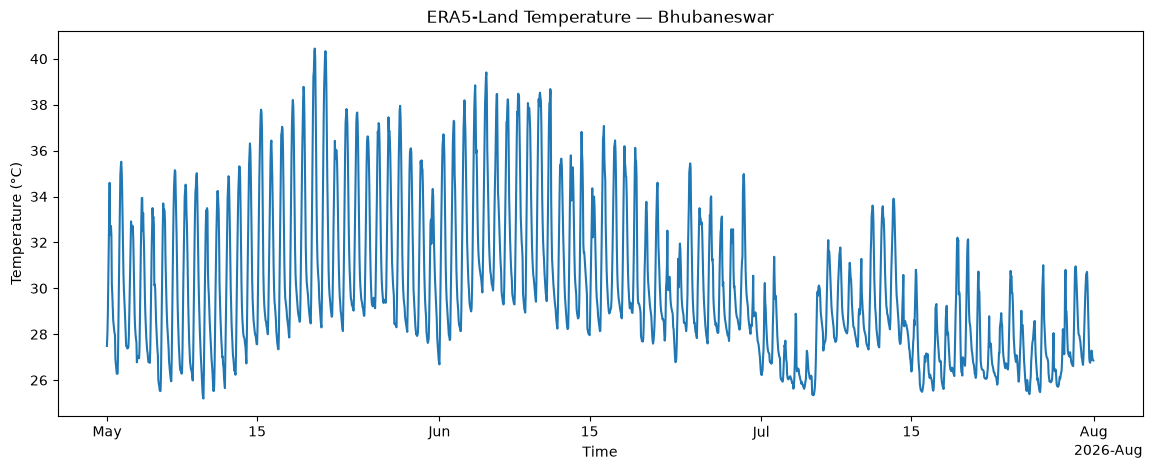

In [29]:
bhubaneswar["temperature_c"].plot(figsize=(14, 5))

plt.title("ERA5-Land Temperature — Bhubaneswar")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

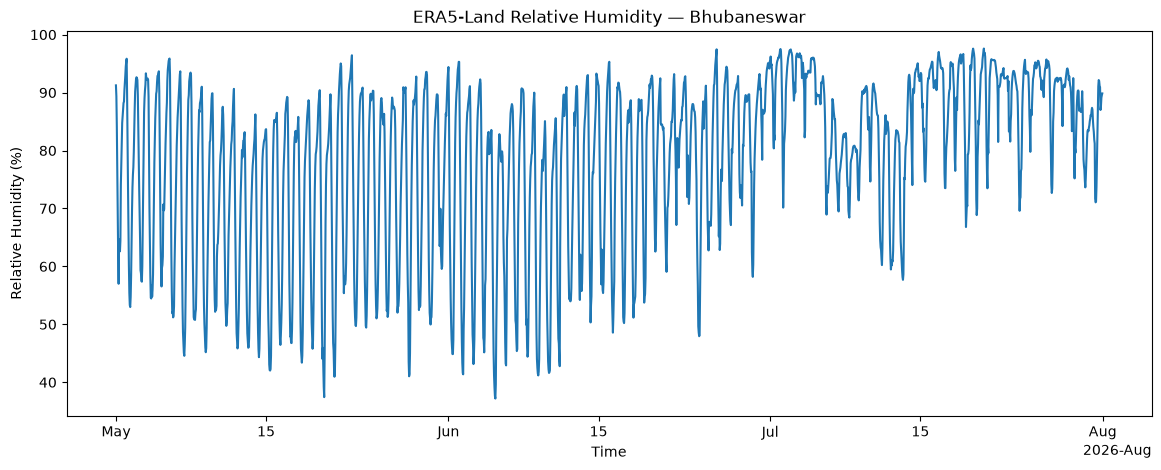

In [30]:
bhubaneswar["relative_humidity_pct"].plot(figsize=(14, 5))

plt.title("ERA5-Land Relative Humidity — Bhubaneswar")
plt.xlabel("Time")
plt.ylabel("Relative Humidity (%)")
plt.show()